wstępe przygotownanie danych

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/SuperStoreOrders.csv')
df

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.1400,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.0360,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.6400,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.0550,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.7700,4.70,Medium,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,31/12/2014,4/1/2015,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,31/12/2014,5/1/2015,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,31/12/2014,2/1/2015,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,31/12/2014,6/1/2015,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [ ]:
df.dtypes

,0
order_id,object
order_date,object
ship_date,object
ship_mode,object
customer_name,object
segment,object
state,object
country,object
market,object
region,object


In [ ]:
df.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


In [ ]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


konwersja typów

In [ ]:
#liczby sales oryginalnie były oddzielane przecinkiem przez co podczas zwykłej konwersji z liczb tysięcznych wychodziły cyfry np. 1,012 na 1 zamiast 1012
df['sales'] = df['sales'].astype(str).str.replace(',', '')
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [ ]:
cols_numeric = ['quantity', 'discount', 'profit', 'shipping_cost']

df[cols_numeric] = df[cols_numeric].apply(pd.to_numeric, errors='coerce')

In [ ]:
cols_category = [
    'ship_mode', 'segment', 'country', 'market',
    'region', 'category', 'sub_category', 'order_priority'
]

for col in cols_category:
    df[col] = df[col].astype('category')

konwersja dat

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'], format='%d/%m/%Y')
df['ship_date'] = pd.to_datetime(df['ship_date'], format='%d/%m/%Y')

nowe kolumny

In [ ]:
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['shipping_time'] = (df['ship_date'] - df['order_date']).dt.days

In [ ]:
print(df.isnull().sum())

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
order_year        0
order_month       0
shipping_time     0
dtype: int64


In [ ]:
print(df.isnull().sum())
print(df.describe())

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
order_year        0
order_month       0
shipping_time     0
dtype: int64
                          order_date                      ship_date  \
count                          51290                          51290   
mean   2013-05-11 21:26:49.155780864  2013-05-15 20:42:42.745174528   
min              2011-01-01 00:00:00            2011-01-03 00:00:00   
25%              2012-06-19 00:00:00            2012-06-23 00:00:00   
50%              2013-07-08 00:00:00            2013-07-12 00:00:00   
75%              2014-05-22 00:00:00            2014-05-26 00:00:00   
max       

Przeprowadzono walidację i konwersję typów danych, zapewniając spójność numeryczną i prawidłową analizę daty i czasu na potrzeby analizy opartej na czasie.

In [ ]:
df.to_csv("cleaned_superstore.csv", index=False)

wstępna analiza

Największa sprzedaż i zysk

In [ ]:
df.groupby('product_name')[['sales', 'profit']].sum().sort_values(by='sales', ascending=False).head(10)

,sales,profit
product_name,,
"Apple Smart Phone, Full Size",86936,5921.5786
"Cisco Smart Phone, Full Size",76441,17238.5206
"Motorola Smart Phone, Full Size",73159,17027.1130
"Nokia Smart Phone, Full Size",71904,9938.1955
Canon imageCLASS 2200 Advanced Copier,61600,25199.9280
"Hon Executive Leather Armchair, Adjustable",58200,5997.2541
"Office Star Executive Leather Armchair, Adjustable",50667,4710.9840
"Harbour Creations Executive Leather Armchair, Adjustable",50120,10427.3260
"Samsung Smart Phone, Cordless",48654,-198.0900


Podział na regiony

In [ ]:
region_analysis = df.groupby('region')[['sales', 'profit']].sum().sort_values(by='sales', ascending=False)

/tmp/ipykernel_509/1528031848.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_analysis = df.groupby('region')[['sales', 'profit']].sum().sort_values(by='sales', ascending=False)


In [ ]:
region_analysis

,sales,profit
region,,
Central,2822399,311403.98164
South,1600960,140355.76618
North,1248192,194597.95252
Oceania,1100207,121666.64200
Southeast Asia,884438,17852.32900
North Asia,848349,165578.42100
EMEA,806184,43897.97100
Africa,783776,88871.63100
Central Asia,752839,132480.18700


analiza w czasie

In [ ]:
monthly_sales = df.groupby(['order_year', 'order_month'])['sales'].sum().reset_index()
monthly_sales

,order_year,order_month,sales
0,2011,1,98902
1,2011,2,91152
2,2011,3,145726
3,2011,4,116927
4,2011,5,146762
5,2011,6,215214
6,2011,7,115518
7,2011,8,207570
8,2011,9,290230
9,2011,10,199070


In [ ]:
monthly_sales = (
    df
    .set_index('order_date')
    .resample('M')['sales']
    .sum()
)

/tmp/ipykernel_509/4066909088.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')['sales']


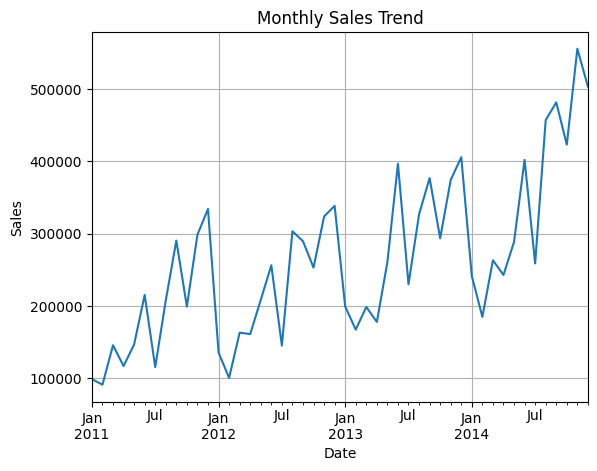

In [ ]:
import matplotlib.pyplot as plt

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid()

plt.show()

Średnie czasy dla każdego rodzaju shippingu

In [ ]:
shipping_analysis = df.groupby('ship_mode')['shipping_time'].mean()
shipping_analysis

/tmp/ipykernel_509/1665855372.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shipping_analysis = df.groupby('ship_mode')['shipping_time'].mean()


,shipping_time
ship_mode,
First Class,2.181746
Same Day,0.037394
Second Class,3.230187
Standard Class,4.998018


Segmentacja klientów

In [ ]:
customer_sales = df.groupby('customer_name')['sales'].sum()

# podział na grupy
df['customer_segment_value'] = pd.qcut(df['sales'], q=3, labels=['low', 'medium', 'high'])
customer_sales

,sales
customer_name,
Aaron Bergman,24646
Aaron Hawkins,20759
Aaron Smayling,14207
Adam Bellavance,20189
Adam Hart,21720
...,...
Xylona Preis,12202
Yana Sorensen,20034
Yoseph Carroll,20165


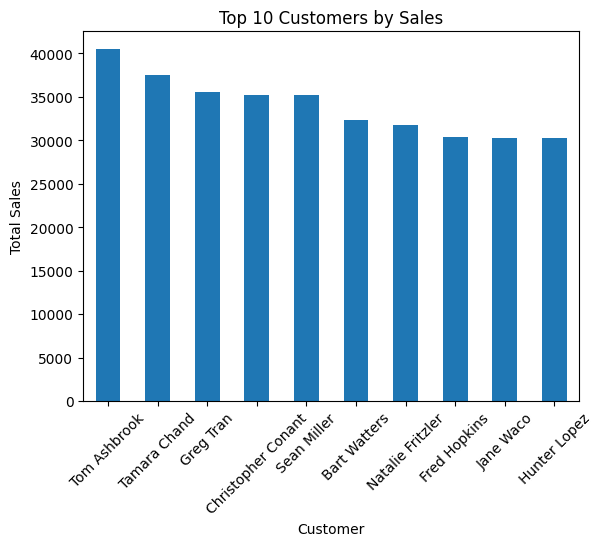

In [ ]:
customer_sales = (
    df.groupby('customer_name')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)



customer_sales.plot(kind='bar')

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

Korelacja

In [ ]:
print(df[['sales', 'profit', 'discount', 'shipping_time']].corr())

                  sales    profit  discount  shipping_time
sales          1.000000  0.485944 -0.086728      -0.004661
profit         0.485944  1.000000 -0.316375       0.001543
discount      -0.086728 -0.316375  1.000000      -0.001507
shipping_time -0.004661  0.001543 -0.001507       1.000000


Feature Engineering

In [ ]:
df['profit_margin'] = df['profit'] / df['sales']
df['is_profitable'] = df['profit'] > 0

In [ ]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,profit,shipping_cost,order_priority,year,order_year,order_month,shipping_time,customer_segment_value,profit_margin,is_profitable
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,106.140,35.46,Medium,2011,2011,1,5,high,0.260147,True
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,36.036,9.72,Medium,2011,2011,1,7,medium,0.300300,True
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,29.640,8.17,High,2011,2011,1,4,medium,0.449091,True
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,-26.055,4.82,High,2011,2011,1,4,medium,-0.579000,False
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,37.770,4.70,Medium,2011,2011,1,7,medium,0.331316,True


Finalny export do csv

In [ ]:
df.to_csv("fact_table.csv", index=False)
monthly_sales.to_csv("monthly_sales.csv", index=False)
region_analysis.to_csv("region_summary.csv")

In [ ]:
from google.colab import files
files.download("fact_table.csv")
files.download("cleaned_superstore.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>